In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import shapiro
import scipy.stats as stats
from scipy.optimize import brentq
from scipy.integrate import quad

from dateutil import parser
from dateutil.tz import tzutc

sns.set_style('darkgrid')

**Pricing Asian Options**

An Asian option is a type of exotic option whose payoff is determined by the arithmetic average of the underlying asset from initiation to expiration. Precisely, if $S_t$, $0 \leq t \leq T$, is the asset price at time $t$, then an ***Asian Call*** with stike $K$ and expiration $T$ on $(S_t)$ is the option whose payoff at time $T$ is $$C_{A} := \left( \frac{1}{T} \int_0^T S_t dt - K \right)^+.$$

The price of an Asian call at time $t$ is the usual expected value of the payoff, discounted to time $t$: $$e^{-r(T-t)} \cdot \mathbb{E} \left[C \vert \mathcal{F}_t\right]$$

Assume that $S_t$ is a geometric Brownian motion: $$dS_t = rS_t dt + \sigma S_t dB_t,$$ where $B_t$ is the standard Brownian motion. When considering a European option, the price has an explicit formula. This is the Black--Scholes formula. In the the case of Asian options, there is no such closed form formula to calculate the price. Despite this, there are still some easy observations one can make about

In [4]:
def GBM_paths(S0, sigma, t, r, mu, n_sims, n_steps):
    """Simulates stock paths as geometric Brownian Motions
    Inputs:
    S0 (float): Underlying stock price at time 0
    sigma (float): Yearly volatility
    t (float): Time to expiration (years)
    r (float): Risk-free interest rate
    mu (float): Drift of log-returns
    n_sims (int): Number of simulated paths
    n_steps (int): Number of steps in each simulated path, each step interval has length t/n_steps
    
    Return (np.array): Array of stock paths
    """
    
    dt = t/n_steps
    noise = np.random.normal(loc = 0, scale = 1, size = (n_sims, n_steps))
    log_returns = (mu+r-sigma**2*(0.5))*dt + sigma*np.sqrt(dt)*noise
    exponent = np.cumsum(log_returns, axis = 1)
    paths = S0*np.exp(exponent)
    paths_with_start = np.insert(paths, 0, S0, axis = 1)

    return paths_with_start

# Black-Scholes Call Value

def bs_call(S0, K, sigma, t, r):
    '''
    Black-Scholes Call Option formula
    
    Inputs:
    S0 (float): Stock price at time 0
    K (float): Strike Price
    sigma: Yearly volatility
    t: Time to expiration (years)
    r: Risk-free Interest rate
    
    
    Return:
    Black-Scholes value of call option (float)
    '''
    
    d1 = (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    
    d2 = d1 - sigma*np.sqrt(t)
    
    
    call_value = S0*norm.cdf(d1) - K*np.exp(-r*t)*norm.cdf(d2)
    
    
    return call_value

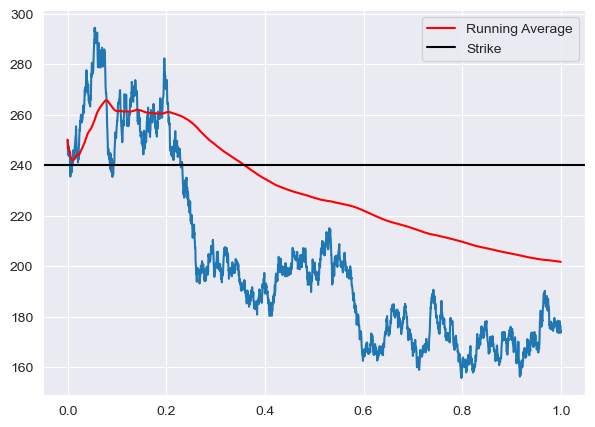

In [204]:
S0 = 250 #Initial Stock Price

K = 240 #Strike Price

sigma = .41 #Volatility

t = 1 #Expiration

r = 0.035 #Risk-free interest rate

mu = 0 #Drift

n_sims = 1 #Number of sample stock paths

n_steps = 2520 #Number of time steps

times = np.linspace(0, t, n_steps + 1)

dt = t/n_steps


stock_paths = GBM_paths(S0, sigma, t, r, mu, n_sims, n_steps)

cumulative_avg_stock_prices = np.cumsum(stock_paths, axis = 1) / np.repeat(np.array([np.arange(1, n_steps+2)]), n_sims, axis = 0) 
# The average stock price at each time step

plt.figure(figsize = (7,5))

plt.plot(times, stock_paths[0])

plt.plot(times, cumulative_avg_stock_prices[0], color = 'red', label = 'Running Average')

plt.axhline(K, label = 'Strike', color = 'black')

plt.legend()

plt.show()

In [6]:
# Monte-Carlo Simulation to Price Asian Options

# The function below calculates a Monte Carlo estimate of the Asian call price, starting at time 0

def asian_call_price_mc(S0, K,sigma,t,r,n_sims = 1000,n_steps = 2520): #Function that returns a 1x2 array. 
                                                                        #One entry is the Monte-Carlo estimate of the price of the Asian Call.
                                                                        #The other entry is the standard error of the estimate. 
    stock_paths = GBM_paths(S0, sigma, t, r, 0, n_sims, n_steps)
    
    avg_val_of_stocks = np.mean(stock_paths, axis = 1) #mean of each stock path
    
    payoffs = np.maximum(avg_val_of_stocks - K, 0) # Call payoffs
    
    prices = np.exp(-r*t) * payoffs #discounting to time 0
    
    return [np.average(prices), np.std(prices)/np.sqrt(n_sims)] # Actual estimate is zero-th entry of the resulting array
                                                                # The standard error of the estimate is the first entry 



In [7]:
# Accuracy of MC method to calculate Asian call price

t = 1

n_sims = 10000

MC_estimate = asian_call_price_mc(S0, K,sigma,t,r,n_sims)

std_err = MC_estimate[1]

print(f'MC estimate with {n_sims} simulations: ${MC_estimate[0]:.2f} and standard error {std_err:.5f}')

# My computer can only run the calculation when n_sims ~ 10^4...


MC estimate with 10000 simulations: $30.40 and standard error 0.45430


In [8]:
# Checking that the Monte-Carlo pricing agrees with our intuition

# We know that the Asian call price is bounded above by the corresponding European call. 

t = 1

print(f'MC estimate with {n_sims} simulations: ${MC_estimate[0]:.2f}. European call price: ${bs_call(S0,K,sigma,t,r)}.')

# We also know that the price of an Asian call (theoretically) converges to 0 as the time to expiration becomes large

times_to_exp = [1,10,50,100,200,300,400]

for t in times_to_exp:
    MC_estimate = asian_call_price_mc(S0, K,sigma,t,r,n_sims)
    std_err = MC_estimate[1]
    print(f'MC estimate with {n_sims} simulations: ${MC_estimate[0]:.2f} and standard error {std_err:.5f}')

MC estimate with 10000 simulations: $30.40. European call price: $48.909218476531976.
MC estimate with 10000 simulations: $30.47 and standard error 0.45147
MC estimate with 10000 simulations: $79.45 and standard error 2.02407
MC estimate with 10000 simulations: $99.17 and standard error 13.33978
MC estimate with 10000 simulations: $57.87 and standard error 20.89999
MC estimate with 10000 simulations: $37.45 and standard error 27.86083
MC estimate with 10000 simulations: $1.59 and standard error 0.79418
MC estimate with 10000 simulations: $0.03 and standard error 0.01449


In [9]:
# This function refines the one above, calculating a Monte Carlo estimate from ANY time between initiation and expiration.

def asian_call_price_middle_mc(S_t, K, Avg_t, t, sigma, T,r,n_sims = 1000,n_steps = 2520): # Function that returns a 1x2 array. 
                                                                        # One entry is the Monte-Carlo estimate of the price of the Asian Call
                                                                        # given that we are at time t.
                                                                        # The other entry is the standard error of the estimate. 
    stock_paths = GBM_paths(S_t, sigma, T-t, r, 0, n_sims, n_steps)
    
    avg_val_of_stocks = np.mean(stock_paths, axis = 1) # Mean of each stock path starting from time t, ending at time T

    total_average = (t*Avg_t + (T-t)*avg_val_of_stocks)/T #average value of entire stock path, from time 0 to time T
    
    payoffs = np.maximum(total_average - K, 0) # Call payoffs
    
    prices = np.exp(-r*(T-t)) * payoffs #discounting to time t
    
    return [np.average(prices), np.std(prices)/np.sqrt(n_sims)] # Actual estimate is zero-th entry of the resulting array
                                                                # The standard error of the estimate is the first entry 

In [10]:
S_t = 250
K = 240
Avg_t = 250
t = 0
sigma = .41
T = 1
r = 0.035


asian_call_price_middle_mc(S_t, K, Avg_t, t, sigma, T,r,n_sims = 10000,n_steps = 2520)

[np.float64(30.51694637087055), np.float64(0.45489677198648515)]

**Caclulating $\Delta$**

In finance, the symbol $\Delta$ denotes the partial derivative of the value of a portfolio with respect to the current underlying stock price. In the Black--Scholes setting of European options, $\Delta$ may be calculated explicitly via a closed-form formula. For Asian options, the situation is trickier. The dependence of the payoff on the path impedes the existence of a formula for $\Delta$. Of course, it is still possible to estimate $\Delta$ vai Monte Carlo methods. We discuss two such methods. 

The first method is the so-called "finite-difference" method. This is the simplest approach by simply using the limit definiton of the derivative: $$\Delta \approx \frac{C_A(S_t + h) - C_A(S_t - h)}{2h}.$$ Here $C_A$ is the payout of the Asian call, $t$ is the current time, $S_t$ is the stock price at time $t$, and $h$ is a small positive number. There are two quantities to estimate: $C_A(S_t+h)$ and $C_A(S_t - h)$. We've already written a function above that estimates both of these quantities via Monte Carlo methods, so we can simply plug in those estimates and see what we get. 

In [ ]:
# Finite-Difference Method to estimate Delta

def asian_call_delta_fd( # Naive approach: directly using limit definition
    S_t, # Current Stock Price
    K, # Strike
    Avg_t, #Current Running Average
    t, # Current time
    sigma, T, r, # Volatility, Time to Exp, Risk-free interest rate
    n_sims, # Number of simulations
    h # Perturbation in stock price
):
    p1 = asian_call_price_middle_mc(S_t+h, K, Avg_t, t, sigma, T,r,n_sims,n_steps = 2520)[0] # Price estimate when stock is at S_t + h
    p2 = asian_call_price_middle_mc(S_t-h, K, Avg_t, t, sigma, T,r,n_sims,n_steps = 2520)[0] # Price estimate when stock is at S_t - h 
    return (p1-p2)/(2*h) # Estimate of Delta

# This approach is BAD. It gives very silly and inconsistent answers. I'm guess this is probably due to the fact that the Monte Carlo method 
# to calculate the Asian prices is already not great and the error from that is compounding. 


Below, we check some of the estimates we get through the finite-difference method. Note here that we use $n = 10000$ sample stock paths to estimate $C_A(S_t + h)$ and $C_A(S_t-h)$.

In [ ]:
S_t = 250
K = 240
Avg_t = 250
t = 0
sigma = .41
T = 1
r = 0.035
n_sims = 10000




In [106]:
## Pathwise approach

# In this approach, assume that the running average is calculated at a fixed number of dates. 

# Interchanging the expectation and the derivative, when we are at time t, the derivative (w.r.t. S_t) of the payoff becomes 
# e^(-r(T-t)) * (1/n_steps) * \sum_i (S_i/S_t) if the payoff > K. Otherwise the derivative vanishes. The sum runs over i occuring AFTER t (inclusive). 
# So we need to estimate the expected value of this expression.

def asian_call_delta_pw(
    S_t, # Current Stock Price
    K, # Strike
    Avg_t, #Current Running Average
    t, # Current time
    sigma, T, r, # Volatility, Time to Exp, Risk-free interest rate
    n_sims, # Number of simulations
    n_steps = 2520
):
    steps_after_t = int(np.ceil(((T-t)/T) * n_steps)) # Number of steps before the current time t
    
    steps_before_t = int(np.floor((t/T) * n_steps)) # Number of steps after the current time t
    
    paths_starting_at_t = GBM_paths(S_t, sigma, T-t, r, 0, n_sims, steps_after_t) # Simulated paths starting at time t

    total_avg = (steps_before_t * Avg_t + np.sum(paths_starting_at_t,axis=1))/(n_steps) # Final averages of the paths at expiration

    avg_minus_strike = total_avg - K # Final averages minus the strike price
    
    payoffs = np.maximum(avg_minus_strike,0) # The payoffs of the paths at expiration
    
    ratios_of_stock_to_current = paths_starting_at_t / S_t # Terms of the sum appearing in the derivative of the payoff expression

    sum_of_ratios = np.sum(ratios_of_stock_to_current, axis = 1) # Adding the terms of the sum 
    
    deriv_of_payoffs = np.exp(-r*(T-t)) * np.sign(payoffs) * np.exp(-r*(T-t)) * sum_of_ratios / n_steps # Calculating the derivative of the payoff

    return [np.average(deriv_of_payoffs), np.std(deriv_of_payoffs)/np.sqrt(n_sims)] # Array that has the Monte Carlo estimate of the Delta,
                                                                                    # the expected value of the derivative of the payoff,
                                                                                    # along with the standard error of the estimate.

In [152]:
S_t = 250
K = 240
Avg_t = 250
t = 0
sigma = .41
T = 1
r = 0.035
n_sims = 10000

delta = asian_call_delta_pw(S_t,K,Avg_t, t, sigma, T,r,n_sims, n_steps)
delta

[np.float64(0.6036803576448351), np.float64(0.005715365603313608)]

In [171]:
# A delta hedging strategy using the Monte Carlo estimate of Delta above

###### First, without hedging.

S_0 = 250
K = 240
t = 0
sigma = .41
T = 1
r = 0.035
n_sims = 10000

# We will consider a portfolio consisting of 100 Asian Calls with the data given above. Let's see the distribution of the profit.

val_of_portfolio = 100 * asian_call_price_mc(S0, K,sigma,T,r,n_sims)[0] #Estimated value of the portfolio 

premium = 100 * asian_call_price_mc(S0, K,sigma+0.01,T,r,n_sims)[0] # Premium we sell the portfolio at.

print(f'Value of portfolio consisting of 100 Asian calls is ${val_of_portfolio:.2f}')

print(f'Premium we will sell the portfolio at: ${premium:.2f}')

Value of portfolio consisting of 100 Asian calls is $3018.84
Premium we will sell the portfolio at: $3082.65


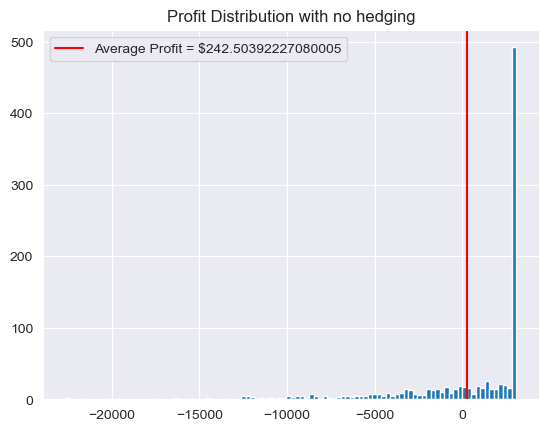

In [172]:
# Now we simulate the profits of the portfolio with NO hedging, from the perspective of the seller.

# We simulate 1000 stock paths and check the profit of the by selling the portfolio for it's value.

n_sims = 1000
n_steps = 2520

sample_paths = GBM_paths(S0, sigma, T, r, mu, n_sims, n_steps)

payouts = 100 * np.maximum(np.average(sample_paths, axis = 1) - K, 0)

profits = premium - np.exp(-r*T) * payouts

avg_profit = np.average(profits)

plt.title('Profit Distribution with no hedging')
plt.hist(profits, bins = 100)

plt.axvline(avg_profit, label = f'Average Profit = ${avg_profit}', color = 'red')
plt.legend()
plt.show()

Unsurprisingly, the average profit is (very close to) 0. Looking at the distribution, we see that roughly half of the time, we get a big profit. Despite this, the potential negative profits are both severe enough and frequent enough that the average profit is near $0$. Now let's see if we can hedge away the big losses.

In the code block below, we collect some calculations needed to simulate hedging. Namely, the running average of the stock price at each time and more importantly, the $\Delta$ at each time we will hedge by buying/selling stock.

In [173]:
# Some calculations we need

hedge_times = np.linspace(0,T, 91)

hedge_points = (hedge_times * n_steps).astype(int)

stock_price_at_hedge_points = sample_paths[:, hedge_points] # The stock prices at the hedge points

cumulative_avg_stock_prices = np.cumsum(sample_paths, axis = 1) / np.repeat(np.array([np.arange(1, n_steps+2)]), n_sims, axis = 0) 
# The average stock price at each time step

cumulative_avg_stock_prices_at_hedge_points = cumulative_avg_stock_prices[:, hedge_points]
# The average stock price at each hedge point

# We will calculate the deltas up at 100 spots 

deltas_at_hedge_points = np.empty((n_sims,90)) # Empty array of shape (n_sims, # of hedges) that we will put the Deltas in

for sim_num in range(0,n_sims): # Running through each sample path, calculating and collecting the Deltas, then placing them into the empty array 
    deltas_at_hedge_points[sim_num] = np.array([asian_call_delta_pw(stock_price_at_hedge_points[sim_num][hedge_spot], K,   # we just defined.
                                             cumulative_avg_stock_prices_at_hedge_points[sim_num][hedge_spot], 
                                             np.linspace(0,T,91)[hedge_spot], sigma,
                                             T, r, n_sims = 100, n_steps = 2520)[0] for hedge_spot in range(0,90)])

deltas_at_hedge_points

array([[0.70557086, 0.6213236 , 0.5900217 , ..., 0.        , 0.        ,
        0.        ],
       [0.51581819, 0.60813686, 0.61294105, ..., 0.03369986, 0.02253907,
        0.01152953],
       [0.63449192, 0.69682458, 0.75348576, ..., 0.03361235, 0.02270216,
        0.01143734],
       ...,
       [0.546889  , 0.58664057, 0.55720999, ..., 0.03362873, 0.02252666,
        0.01150574],
       [0.62402993, 0.6903073 , 0.63754225, ..., 0.03362503, 0.02262885,
        0.01150224],
       [0.57323245, 0.67414777, 0.68745711, ..., 0.        , 0.        ,
        0.        ]])

With the $\Delta$'s in hand, we can now simulate the hedging. Directly beneath the next code block is the profit distribution of our sale of $100$ Asian calls supposing that we hedge $5, 10, 30, 45$, and $90$ times. 

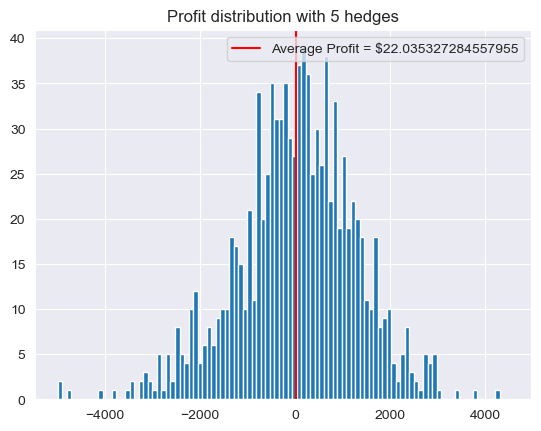

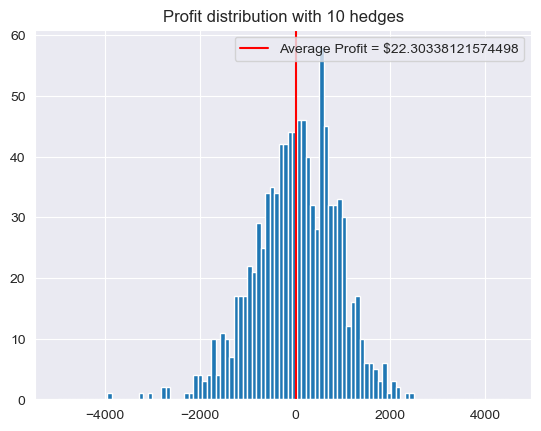

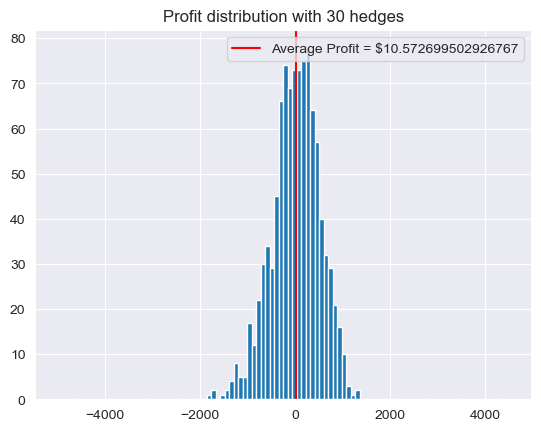

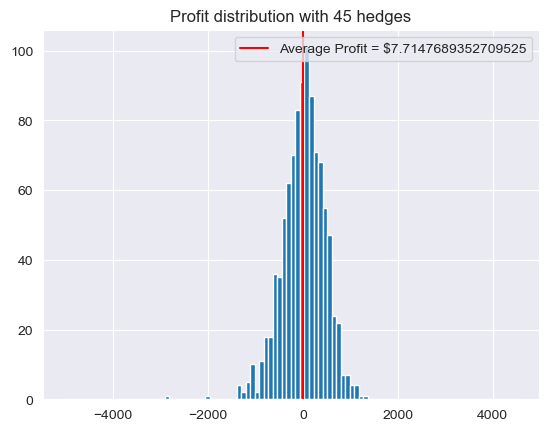

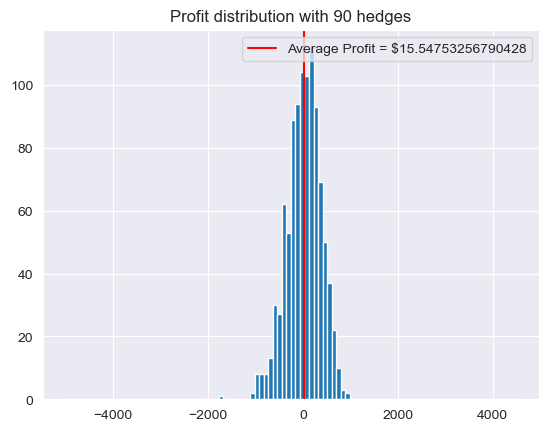

In [202]:
# The profit at the expiration will be the premium + stock profits - payouts

# The payouts and the premium we've already calculated. So now we must calculate the stock profits. Without hedging, stock profits = 0.

hedge_frequencies = [5, 10, 30, 45, 90]

for hedge_frequency in hedge_frequencies:
    hedge_times = np.linspace(0,T, hedge_frequency + 1)

    hedge_points = (hedge_times * n_steps).astype(int) # Time steps at which we are going to hedge the portfolio

    dt = T/hedge_frequency # Time interval between each hedge

    stock_profits_discounted = (sample_paths[:,hedge_points[1:hedge_frequency + 1]] - \
                            sample_paths[:,hedge_points[0:hedge_frequency]]*np.exp(r*dt))*np.exp(-r*hedge_times[1:hedge_frequency+1]) * \
                            deltas_at_hedge_points[:,(np.array(list(range(0, hedge_frequency))) * 90/hedge_frequency).astype(int)] * 100

    total_stock_profits = np.sum(stock_profits_discounted, axis = 1)

    hedged_profits = val_of_portfolio + total_stock_profits - np.exp(-r*T) * payouts

    avg_hedged_profit = np.average(hedged_profits)

    plt.hist(hedged_profits, bins = 100, range = (-5000, 4500))
    plt.axvline(avg_hedged_profit, label = f'Average Profit = ${avg_hedged_profit}', color = 'red')
    plt.title(f'Profit distribution with {hedge_frequency} hedges')
    plt.legend()
    plt.show()

Not so surprisingly, as we hedge more frequently, there are fewer astronomical losses and the profits become increasingly clustered around the average. 

**References**

*Stochastic Calculus for Finance II*, Steven E. Shreve. (2004)

"Estimating the Greeks", Lecture notes by Martin Haugh. Link: https://www.columbia.edu/~mh2078/MonteCarlo/MCS_Greeks.pdf